# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Seth Neon Ruiheng


**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person's work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
## Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay,
)
import joblib

# A single random seed used everywhere -> reproducible results (required for the tuning rubric)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


# 1. Business Understanding

### Problem statement

The Portuguese bank uses direct telephone marketing to encourage customers to subscribe to a
term deposit. However, only 4,640 of the 41,188 recorded contacts resulted in a subscription,
so contacting every customer uses substantial staff time for a relatively small number of
successful outcomes.

### Machine-learning goal

The aim is to develop a model that predicts, **before a call is made**, whether a customer is
likely to subscribe (`y = yes` or `y = no`). This is a binary classification problem because
the target has two possible classes. The model can rank or identify higher-potential customers
so that call-centre agents can focus their limited time on the customers most likely to respond.

### Business value

A useful model can reduce low-value calls, lower the staff time required per successful
subscription, and improve the conversion rate of the customers selected for contact. It should
also retain good recall for the `yes` class because failing to identify a willing customer is a
lost sales opportunity. Therefore, the solution must balance finding more potential subscribers
against sending agents too many customers who will still decline.

### Dataset

The analysis uses the UCI Bank Marketing dataset created from a Portuguese bank's campaigns
between May 2008 and November 2010. It contains 41,188 records, 20 input features, and the target
column `y`.


# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## Read the CSV into a pandas DataFrame.
## NOTE: this file is semicolon-separated (sep=';'), not comma-separated.
df = pd.read_csv('bank-additional-full.csv', sep=';')

print('Rows, columns:', df.shape)
df.head()

Rows, columns: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 2.2 Summary Statistics

In [3]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [4]:
## This dataset encodes missing values as the string 'unknown' rather than NaN.
## Count them per column so we can decide how to handle them in Section 3.
missing_nan = df.isnull().sum()
missing_unknown = (df == 'unknown').sum()
pd.DataFrame({'nan': missing_nan, 'unknown_string': missing_unknown}) \
    .query('nan > 0 or unknown_string > 0')

,nan,unknown_string
job,0,330
marital,0,80
education,0,1731
default,0,8597
housing,0,990
loan,0,990


In [5]:
## Describe the numeric feature distributions
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [6]:

## Describe the categorical features
df.select_dtypes(exclude=np.number).describe()


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548



### Interpretation of summary statistics

- The dataset contains **41,188 rows and 21 columns**. There are no ordinary `NaN` values, but
  missing or unavailable information is stored as the literal category `'unknown'`.
- The target is imbalanced: **36,548 customers (88.73%)** did not subscribe and only
  **4,640 (11.27%)** subscribed. I will therefore use a stratified train-test split, apply class
  weighting where supported, and compare recall, F1 and PR-AUC instead of relying on accuracy.
- `'unknown'` appears most often in `default` (**8,597; 20.87%**) and `education`
  (**1,731; 4.20%**). It also occurs in `housing` and `loan` (**990; 2.40% each**), `job`
  (**330; 0.80%**) and `marital` (**80; 0.19%**). I will retain it as a separate category
  because replacing it with the most common answer would invent information and may remove a
  useful pattern.
- The median and upper quartile of `pdays` are both **999**. This is a sentinel for "not
  previously contacted", not a genuine waiting time of 999 days. I will create a
  `was_previously_contacted` indicator and reset the sentinel to 0 so the numerical scale is
  meaningful.
- `duration` ranges from 0 to 4,918 seconds and is known only after a call ends. Although it is
  likely to predict the target strongly, it will be removed to prevent target leakage in a
  pre-call decision model.
- `campaign` and `previous` have means greater than their medians and much larger maximum
  values, suggesting right-skew and possible outliers. Scaling will support Logistic Regression,
  while tree-based models can learn non-linear splits without requiring normally distributed
  inputs.


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

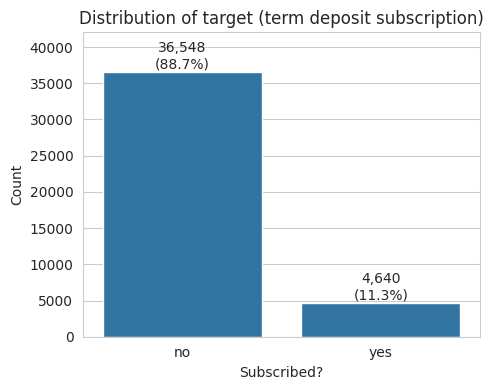

y
no     88.7
yes    11.3
Name: proportion, dtype: float64


In [7]:
## Target distribution
target_counts = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True).mul(100).round(1)

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x='y', order=['no', 'yes'], ax=ax)
ax.set_title('Distribution of target (term deposit subscription)')
ax.set_xlabel('Subscribed?'); ax.set_ylabel('Count')
ax.set_ylim(0, target_counts.max() * 1.15)
for i, v in enumerate(target_counts[['no', 'yes']]):
    ax.text(i, v + target_counts.max() * 0.015,
            f'{v:,}\n({target_pct[["no","yes"][i]]}%)', ha='center')
plt.tight_layout(); plt.show()

print(target_pct)


### Interpretation of target distribution

There are **36,548 `no` cases (88.73%)** and **4,640 `yes` cases (11.27%)**. This is a clear
class imbalance. A majority-class model that predicts `no` for every customer would achieve
88.73% accuracy but identify **zero** potential subscribers, so its business value would be
zero. For this reason, accuracy will be reported but will not be the main selection metric.
I will focus on **F1 for the `yes` class**, while also checking recall and PR-AUC. F1 balances
the need to catch willing customers with the need to avoid sending agents an excessively large
number of customers who will decline.


### 2.3.1.2 Understanding distribution of features

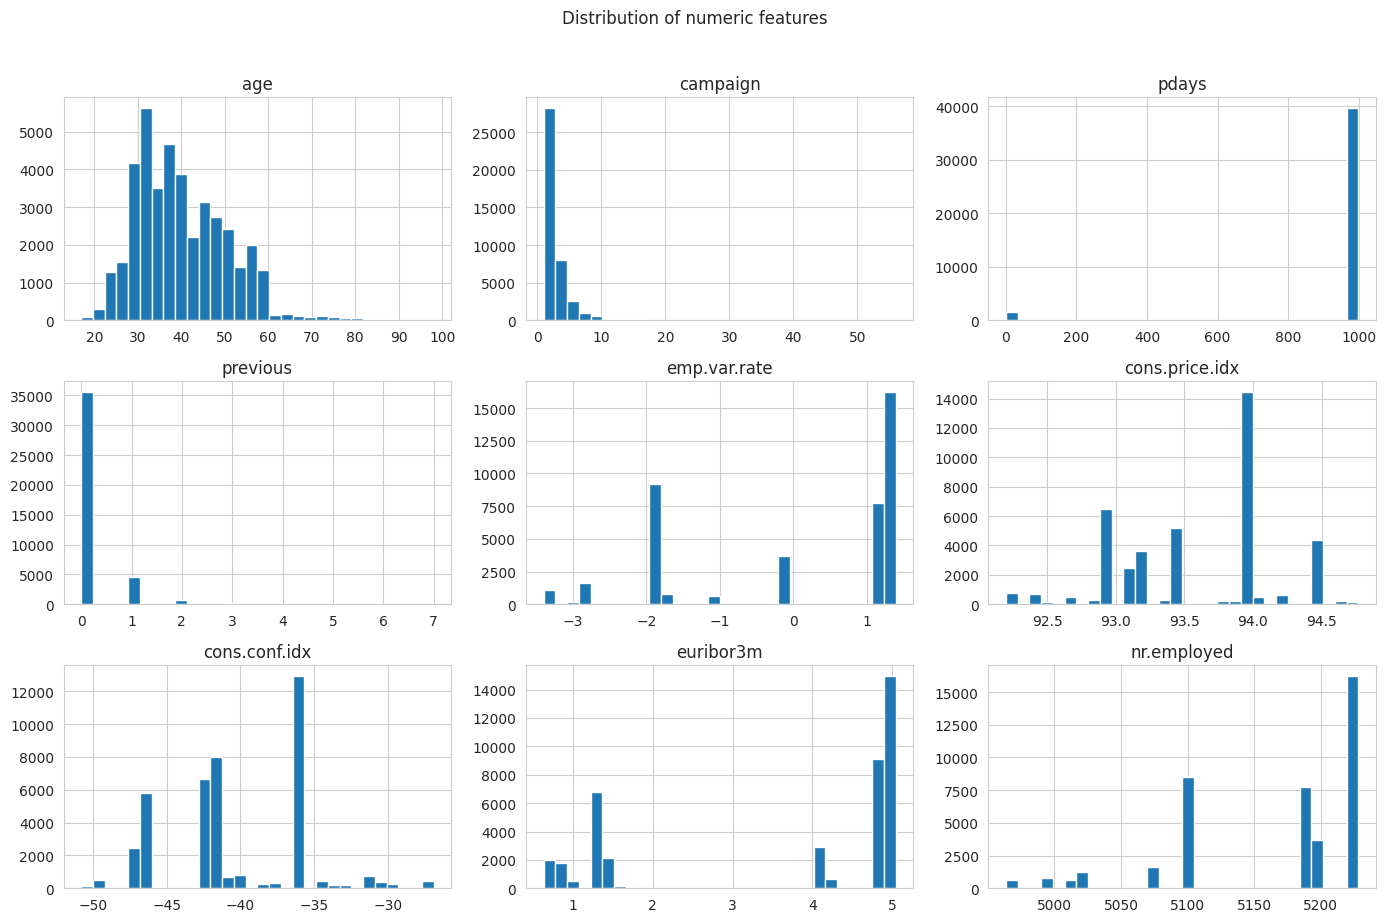

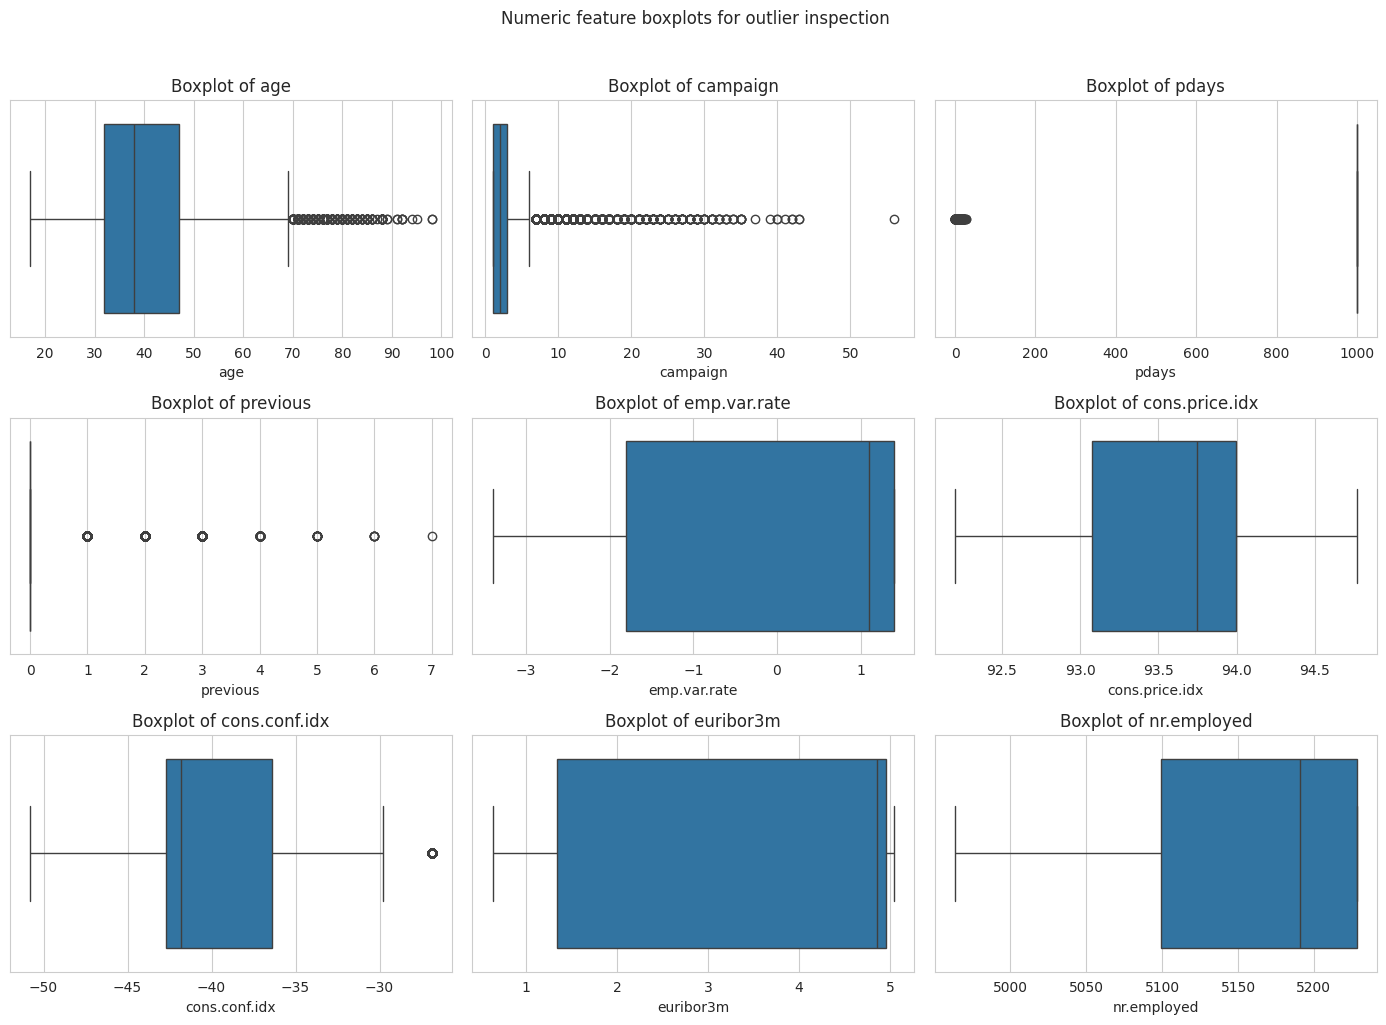

In [8]:

## Numeric feature distributions
numeric_cols = ['age', 'campaign', 'pdays', 'previous',
                'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                'euribor3m', 'nr.employed']

df[numeric_cols].hist(figsize=(14, 9), bins=30)
plt.suptitle('Distribution of numeric features', y=1.02)
plt.tight_layout()
plt.show()

## Boxplots make possible outliers visible without deleting them automatically.
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.boxplot(data=df, x=col, ax=ax)
    ax.set_title(f'Boxplot of {col}')
plt.suptitle('Numeric feature boxplots for outlier inspection', y=1.02)
plt.tight_layout()
plt.show()


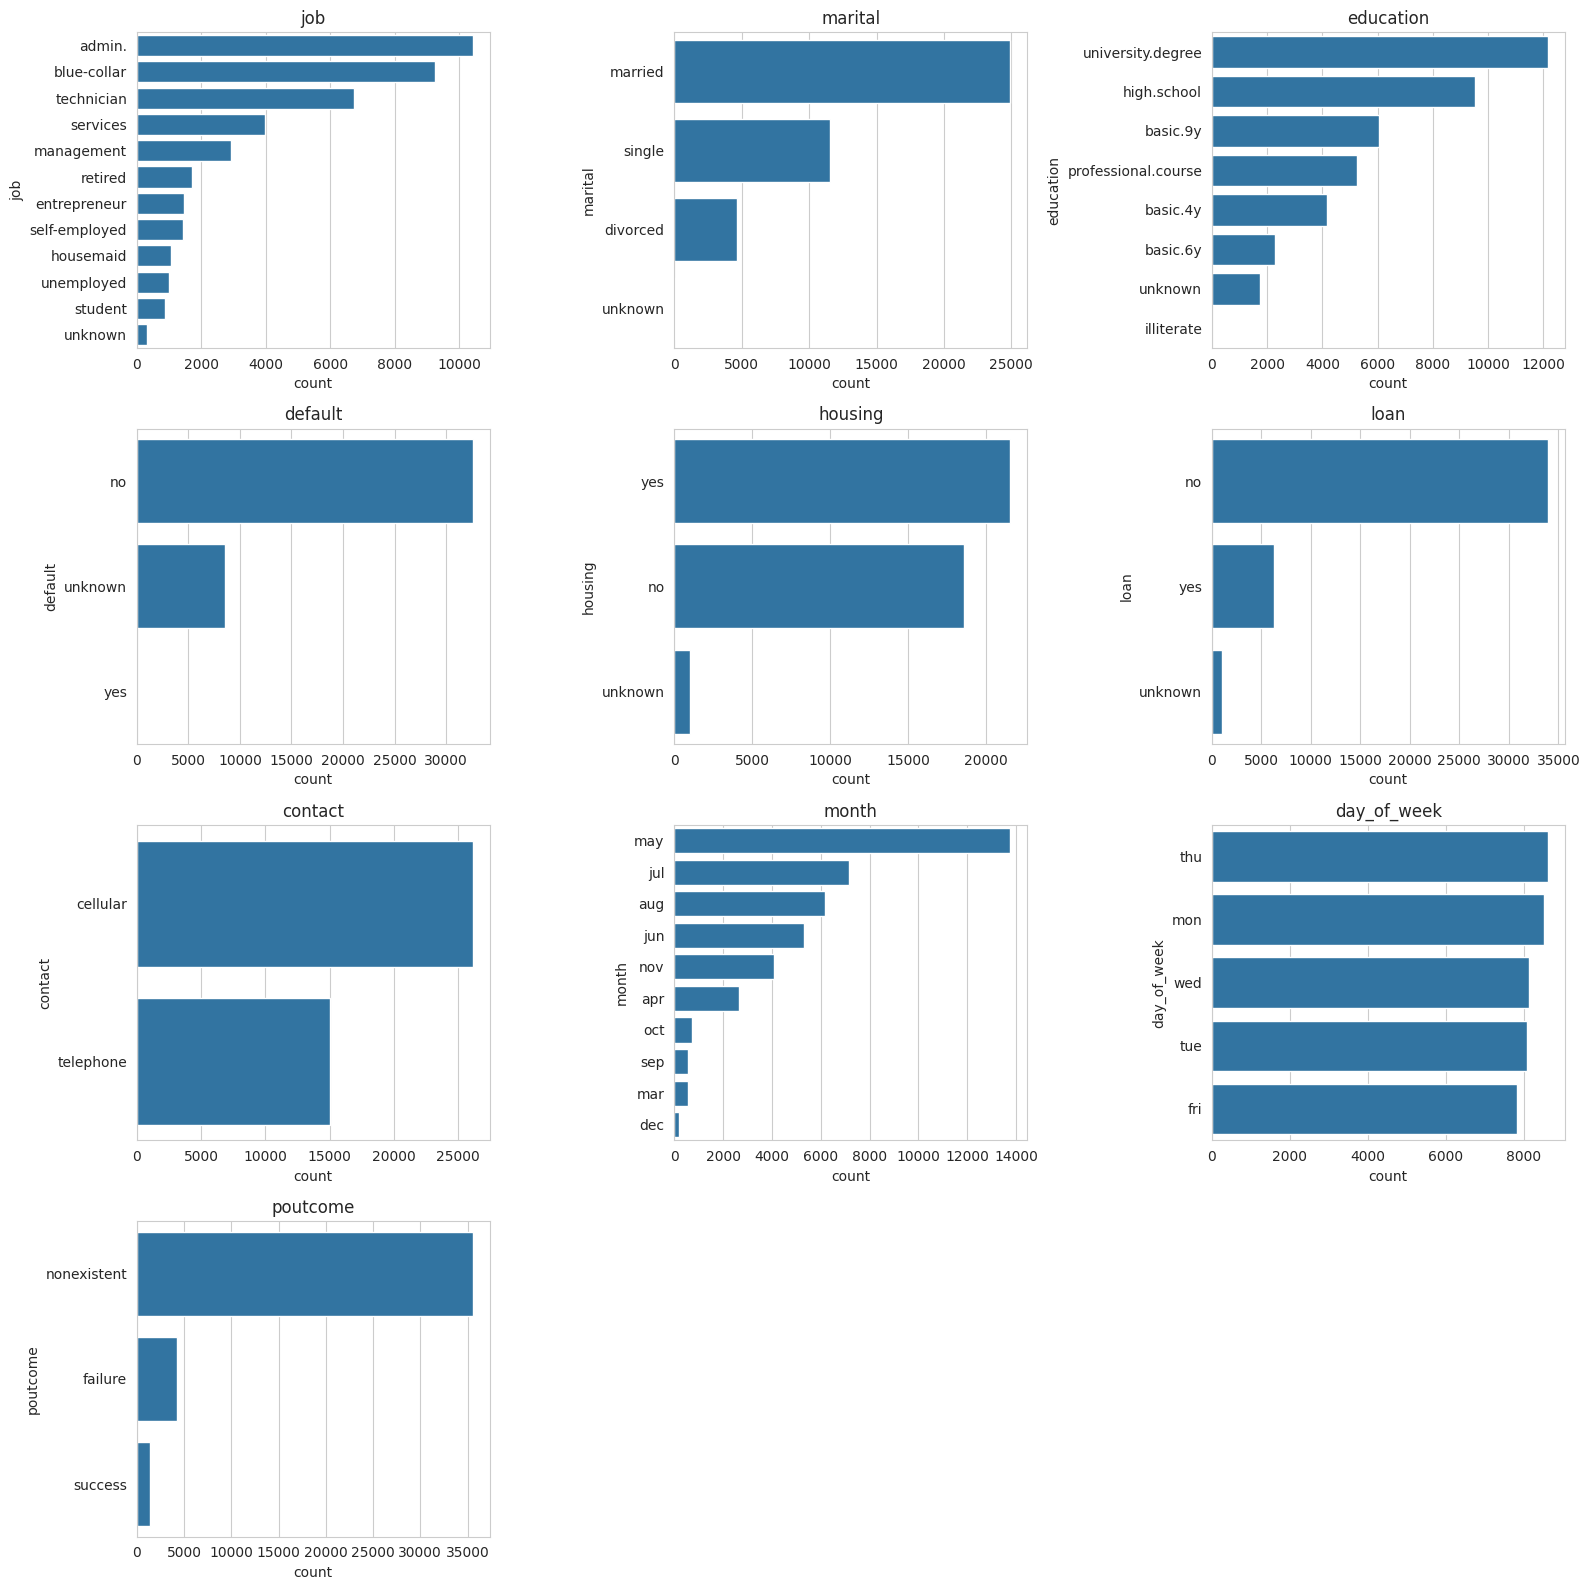

In [9]:
## Categorical feature distributions
categorical_cols = ['job', 'marital', 'education', 'default', 'housing',
                    'loan', 'contact', 'month', 'day_of_week', 'poutcome']

fig, axes = plt.subplots(4, 3, figsize=(16, 16))
for ax, col in zip(axes.ravel(), categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax)
    ax.set_title(col)
for ax in axes.ravel()[len(categorical_cols):]:
    ax.axis('off')
plt.tight_layout(); plt.show()


### Interpretation of feature distributions

**Numeric features**

- `age` is concentrated mainly between the early 30s and late 40s, with a smaller number of
  older customers shown as upper boxplot outliers. These are realistic ages, so they will be
  retained rather than treated as errors.
- `campaign` is strongly right-skewed: most customers received only a few contacts, while the
  maximum is 56. `previous` is also zero-inflated and right-skewed because most customers had
  no earlier campaign contacts. These genuine values will be retained; scaling supports the
  linear model, while the tree models can handle skewed predictors.
- `pdays` is dominated by 999, confirming that most customers were never previously contacted.
  This sentinel must not be interpreted as an extreme outlier. It will be represented using an
  explicit previous-contact flag and a cleaned day count.
- `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m` and `nr.employed` are clustered
  at a limited set of economic conditions because the data was collected during specific
  campaign periods. They will be standardised for Logistic Regression and left available to
  the tree models.

**Categorical features**

- `job` is dominated by `admin.`, `blue-collar` and `technician`; `marital` is mostly
  `married`; and the most common education level is `university.degree`. One-hot encoding will
  preserve these groups without assigning a false numerical order.
- `default` is mostly `no` but has a large `'unknown'` group. `housing` is mostly `yes`, whereas
  `loan` is mostly `no`. The `'unknown'` levels will remain separate so unavailable information
  is not silently changed into a definite answer.
- `contact` has two channels and is dominated by cellular calls. `month` is heavily concentrated
  in May, while `day_of_week` is comparatively balanced. Month will be kept because it may
  capture campaign timing and economic seasonality.
- `poutcome` is mostly `nonexistent`, which is consistent with the large number of customers
  with no previous contact. The rarer `success` and `failure` levels may still be highly useful
  and will be retained.

The boxplots flag unusual values in several numeric columns, but the values are plausible
customer or campaign observations rather than confirmed data-entry errors. I will not remove
rows solely because a boxplot labels them as outliers, which avoids discarding valid rare
customers.


### 2.3.2 Understanding relationship between variables

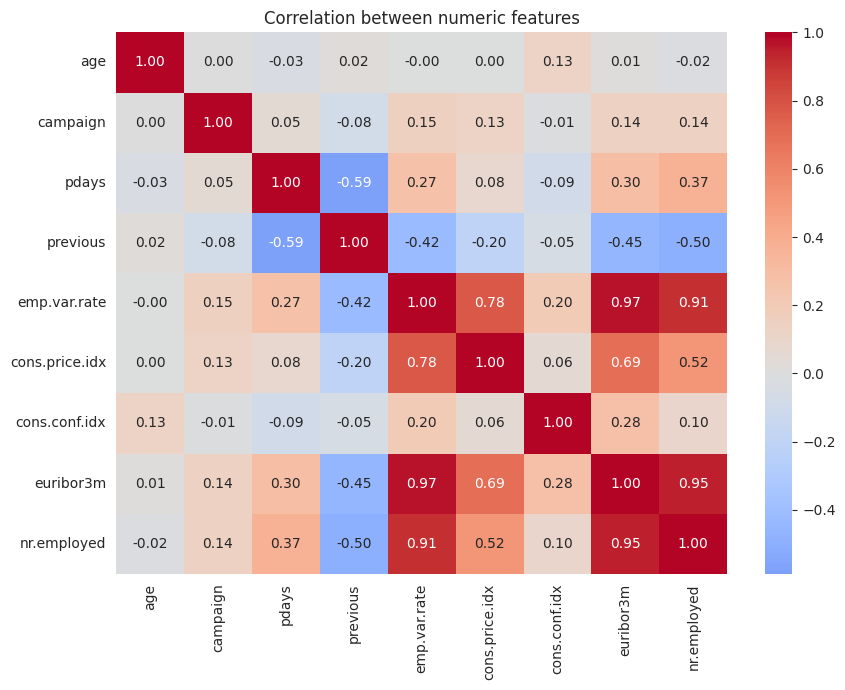

In [10]:
## Correlation between numeric features
plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation between numeric features')
plt.tight_layout(); plt.show()

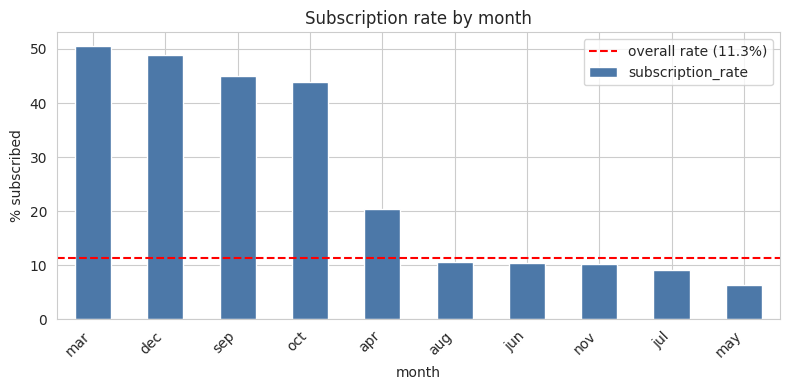

,subscribers,customers,subscription_rate
month,,,
mar,276,546,50.5
dec,89,182,48.9
sep,256,570,44.9
oct,315,718,43.9
apr,539,2632,20.5
aug,655,6178,10.6
jun,559,5318,10.5
nov,416,4101,10.1
jul,649,7174,9.0


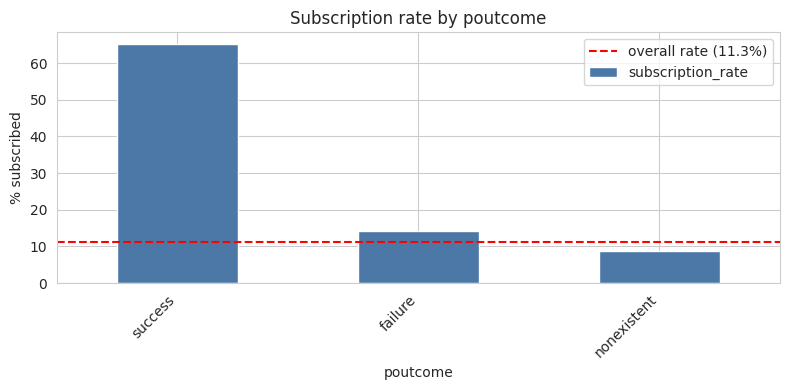

,subscribers,customers,subscription_rate
poutcome,,,
success,894,1373,65.1
failure,605,4252,14.2
nonexistent,3141,35563,8.8


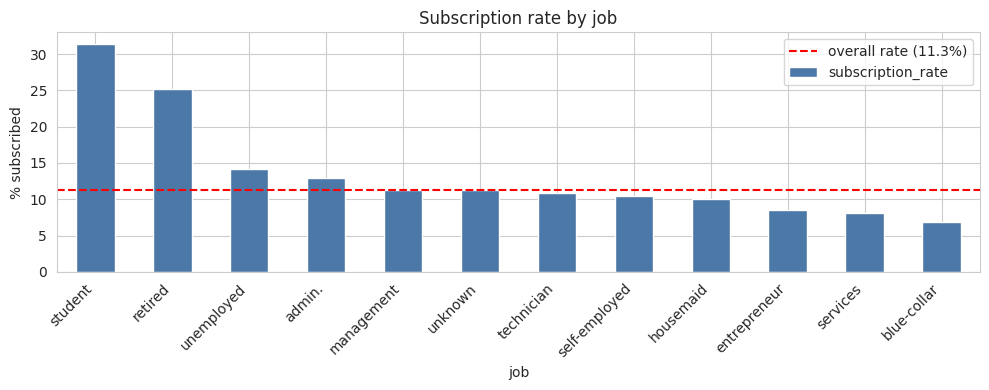

,subscribers,customers,subscription_rate
job,,,
student,275,875,31.4
retired,434,1720,25.2
unemployed,144,1014,14.2
admin.,1352,10422,13.0
management,328,2924,11.2
unknown,37,330,11.2
technician,730,6743,10.8
self-employed,149,1421,10.5
housemaid,106,1060,10.0


In [11]:

## Compare subscription rates for month, previous campaign outcome and job.
overall_rate = df['y'].eq('yes').mean() * 100

def plot_subscription_rate(column, figsize=(8, 4)):
    summary = (
        df.assign(subscribed=df['y'].eq('yes'))
          .groupby(column, observed=False)['subscribed']
          .agg(subscribers='sum', customers='count', subscription_rate='mean')
    )
    summary['subscription_rate'] = summary['subscription_rate'].mul(100)
    summary = summary.sort_values('subscription_rate', ascending=False)

    ax = summary['subscription_rate'].plot(kind='bar', figsize=figsize, color='#4C78A8')
    ax.axhline(overall_rate, color='red', linestyle='--',
               label=f'overall rate ({overall_rate:.1f}%)')
    ax.set_title(f'Subscription rate by {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('% subscribed')
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    display(summary.round({'subscription_rate': 1}))
    return summary

rate_by_month = plot_subscription_rate('month')
rate_by_poutcome = plot_subscription_rate('poutcome')
rate_by_job = plot_subscription_rate('job', figsize=(10, 4))



### Interpretation of relationships between variables

**Correlation heatmap.** The strongest relationships are between `emp.var.rate` and
`euribor3m` (**r = 0.97**), `euribor3m` and `nr.employed` (**r = 0.95**), and
`emp.var.rate` and `nr.employed` (**r = 0.91**). These variables describe the same broad
economic environment, so their high multicollinearity may make individual Logistic Regression
coefficients less stable and harder to interpret. The regularised Logistic Regression pipeline
reduces this issue, and comparison with tree models checks whether non-linear relationships
improve prediction.

**Contact month.** Subscription rates vary greatly by month: March (**50.5%**), December
(**48.9%**), September (**44.9%**) and October (**43.9%**) are far above the overall 11.3%
rate, whereas May is only **6.4%**. Month may capture seasonality and changing economic
conditions, although the high-rate months have fewer observations and should not be interpreted
as proof that the month itself causes subscription.

**Previous campaign outcome.** Customers with a previous `success` have a **65.1%**
subscription rate, compared with **14.2%** after a previous `failure` and **8.8%** when the
outcome is `nonexistent`. This is the clearest categorical relationship with the target and
makes business sense: a customer who responded positively before is more likely to retain
interest. `poutcome` should therefore remain in the model.

**Job.** Students (**31.4%**) and retired customers (**25.2%**) have the highest observed
subscription rates, while blue-collar (**6.9%**) and services (**8.1%**) customers have lower
rates. Job therefore contributes useful segmentation information, but these are associations,
not proof that occupation causes the decision.

Based on these findings, `month`, `poutcome` and `job` will be retained and one-hot encoded.
Model comparison is still required because EDA relationships alone do not prove how well a
feature will generalise to unseen customers.


# 3. Data Preparation

## 3.1 Data Cleaning

In [ ]:
## TODO: Create a cleaned copy of the dataset.
## Decide how to handle 'unknown' values.
## Remove any feature that would leak information unavailable before the call.
## Engineer a meaningful indicator for the pdays=999 sentinel.

### Data-cleaning and feature-engineering decisions

> **Template:** Explain how `'unknown'` will be treated, whether outliers will be removed, why
> `duration` may cause leakage, and how the `pdays=999` sentinel will be represented.

## 3.2 Train-Test Split

> **Template:** Justify the train-test ratio, stratification and random seed. Explain how
> fitting preprocessing only on training data prevents leakage.

In [ ]:
## TODO: Separate features (X) from target (y).
## Create a reproducible, stratified 80:20 train-test split.

In [ ]:
## TODO: Build numeric and categorical preprocessing pipelines.
## Scale numeric features and one-hot encode categorical features.
## Fit preprocessing on training data only.

# 4. Modelling

> **Template:** State the main evaluation metric and explain why it suits the 11.27% positive
> class. Compare a majority-class baseline with at least two different algorithms.

### 4.2 Train Model

In [ ]:
## TODO: Define the majority baseline and candidate classification models.
## Fit every model using the same preprocessing pipeline and train-test split.
## Store accuracy, precision, recall, F1, ROC-AUC and PR-AUC in one comparison table.

### Model comparison and initial selection

> **Template:** Compare the models quantitatively, explain the trade-offs, state whether each
> model beats the baseline, and justify the initial model selected for evaluation.

# 5. Model Evaluation

In [ ]:
## TODO: Evaluate the selected model with a classification report,
## confusion matrix and ROC curve.

### Detailed evaluation of the initial model

> **Template:** Interpret true positives, false positives, true negatives and false negatives
> in business terms. Explain how the model changes which customers the bank should prioritise.

In [ ]:
## TODO: Test the selected pipeline on one unseen customer record.
## Show both the predicted class and probability of subscription.

## Iterative model development

> **Template:** Document the next experiment, why it is being attempted, and whether it
> improves the selected metric. Keep the held-out test set separate from cross-validation.

In [ ]:
## TODO: Inspect feature importance or coefficients.
## Use the result to justify any feature-selection or feature-engineering decision.

### Feature-importance interpretation

> **Template:** State which features appear most influential, explain what the result means,
> and note that importance does not prove causation.

In [ ]:
## TODO: Tune the strongest candidate with RandomizedSearchCV.
## Follow the project rule of no more than three values per hyperparameter.
## Use stratified cross-validation and an evaluation metric suitable for class imbalance.

In [ ]:
## TODO: Compare the untuned and tuned models on the held-out test set.
## Report accuracy, precision, recall, F1, ROC-AUC and PR-AUC.

### Tuning and final-model interpretation

> **Template:** Report the best hyperparameters, compare tuned and untuned performance, discuss
> the precision-recall trade-off, and justify the final deployment model.

In [ ]:
## TODO: Save the final fitted preprocessing-and-model pipeline with joblib.

## References

- Moro, S., Rita, P., & Cortez, P. (2014). *Bank Marketing* [Dataset]. UCI Machine Learning
  Repository. https://doi.org/10.24432/C5K306
- Moro, S., Cortez, P., & Rita, P. (2014). A data-driven approach to predict the success of
  bank telemarketing. *Decision Support Systems, 62*, 22–31.

> **Template:** Add the scikit-learn documentation and other sources used during modelling
> and tuning.